In [1]:
import sys
sys.path.append('../')
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle
from tqdm.auto import tqdm
from scipy.stats import gaussian_kde, pearsonr

from utils import *
from experiment import unpack_and_dequantize
from model import probability_weighting, probability_weighting_goldstein_einhorn, probability_weighting_prelec

import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

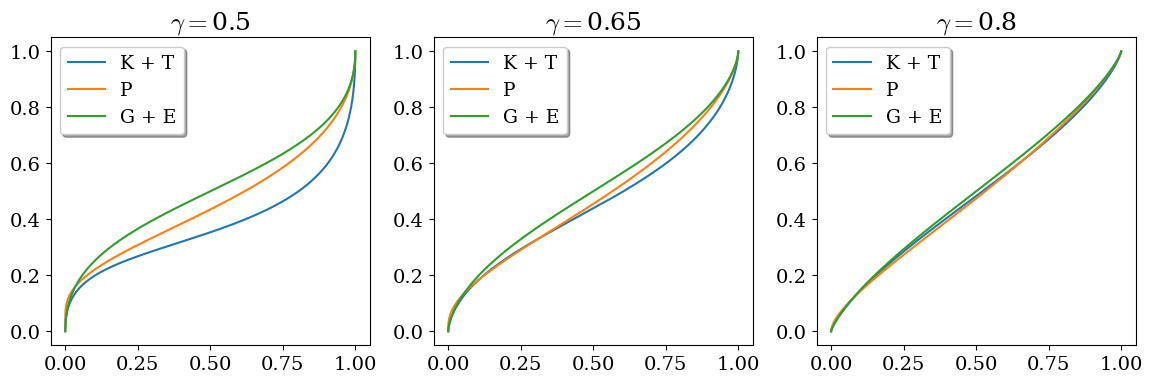

In [2]:
labels = ["K + T", "P", "G + E"]
p = np.linspace(0, 1, 2000)

fig, axs= plt.subplots(1, 3, figsize=(14,4))

for k, g in enumerate([0.5, 0.65, 0.8]):
    for i,f in enumerate([probability_weighting, probability_weighting_prelec, probability_weighting_goldstein_einhorn]):
        axs[k].plot(p, f(p, gamma=g), label=labels[i])
    axs[k].set_title(r"$\gamma=$" + str(g))
    axs[k].legend(shadow=True)

plt.show()

In [5]:
gvals = np.linspace(0.5, 1.0, 100)

v1 = probability_weighting(0.05, gvals)
v2 = 1 - probability_weighting(1-0.05, gvals)


In [ ]:
plt.plot(gvals, v1, labal="V1")
plt.plot(gvals, v2, label="V2")
plt.legend()
plt.xlabel("Gamma")
plt.ylabel("CPT_P_Decrease")
plt.show()

### Welfare

In [5]:
directories = ["cpt_revised_ge", "cpt_revised_kt", "cpt_revised_prelec"]

for D in directories:
    mean = []
    gini = []
    sen = []
    for f in tqdm(os.listdir("../" + D)):
        with open(os.path.join("../" + D, f), "rb") as f:
            res = pickle.load(f)
        wealth = unpack_and_dequantize(res["wealth"][:,-1], 200)
        health = unpack_and_dequantize(res["health"][:,-1], 200)
        util = utility(wealth, health, alpha=res['params']['alpha'])
        m = mean_util(util)
        g = gini_coeff(util)
        s = m * (1-g)
        mean.append(m)
        gini.append(g)
        sen.append(s)
    with open(f"../{D}_sen_welfare", "wb") as f:
        pickle.dump(sen, f)
    with open(f"../{D}_gini", "wb") as f:
        pickle.dump(gini, f)
    with open(f"../{D}_mean_util", "wb") as f:
        pickle.dump(mean, f)

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

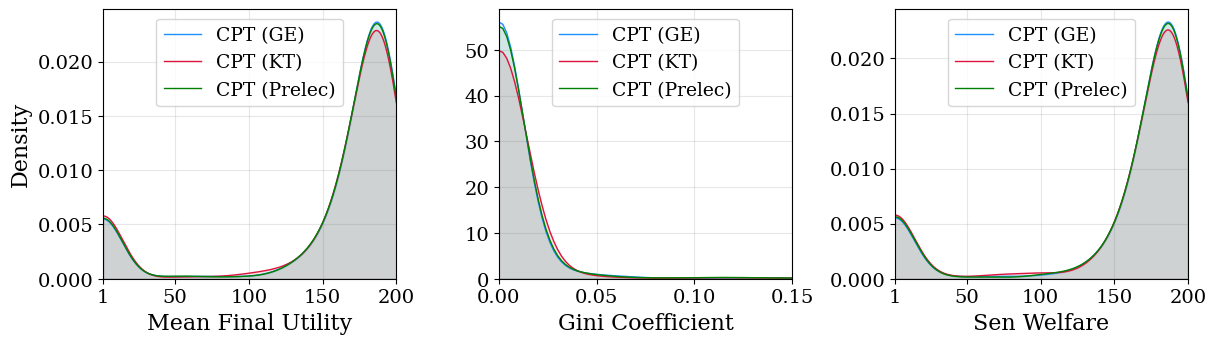

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(14,3.5))
labels = ["CPT (GE)", "CPT (KT)", "CPT (Prelec)"]
colors = ["dodgerblue", "crimson", "green"]

# Mean Final Utility
for i, directory in enumerate(["../cpt_revised_ge", "../cpt_revised_kt", "../cpt_revised_prelec"]):
    with open(f"{directory}_mean_util", "rb") as f:
        M = pickle.load(f)
    kde = gaussian_kde(M, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[0].plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1)
    axs[0].fill_between(x_vals, y_vals, color=colors[i], alpha=0.1)
axs[0].set_ylabel("Density")
axs[0].set_xlabel("Mean Final Utility")
axs[0].legend(loc="upper center")
axs[0].set_ylim(0,)
axs[0].set_xticks([1, 50, 100, 150, 200])
axs[0].grid()
axs[0].set_xlim(1,200)

# Gini Coefficient
for i, directory in enumerate(["../cpt_revised_ge", "../cpt_revised_kt", "../cpt_revised_prelec"]):
    with open(f"{directory}_gini", "rb") as f:
        G = pickle.load(f)
    kde = gaussian_kde(G, bw_method=0.2)
    x_vals = np.linspace(min(G), 1, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[1].plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1)
    axs[1].fill_between(x_vals, y_vals, color=colors[i], alpha=0.1)
axs[1].set_xlabel("Gini Coefficient")
axs[1].legend(loc="upper center")
axs[1].set_xlim(0, 0.15)
axs[1].grid()
axs[1].set_ylim(0,)

# Sen Welfare
for i, directory in enumerate(["../cpt_revised_ge", "../cpt_revised_kt", "../cpt_revised_prelec"]):
    with open(f"{directory}_sen_welfare", "rb") as f:
        sen = pickle.load(f)
    kde = gaussian_kde(sen, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[2].plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1)
    axs[2].fill_between(x_vals, y_vals, color=colors[i], alpha=0.1)
axs[2].set_xlabel("Sen Welfare")
axs[2].set_xticks([1, 50, 100, 150, 200])
axs[2].legend(loc="upper center")
axs[2].grid()
axs[2].set_ylim(0,)
axs[2].set_xlim(1,200)

fig.subplots_adjust(wspace=0.35)
plt.savefig("../figures/cpt_comparison_weighting.pdf", bbox_inches="tight")
plt.show() 